In [123]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

# data_path = r'C:\Users\grace\OneDrive\Desktop\STAT 5630\STAT 5630 Final Project\ChestXRay2017\chest_xray'
data_path = r'C:\Users\songy\Downloads\UVA STAT 5630 Statistical Machine Learning\Project\data\chest_xray'

#### Load the data

In [124]:
image_data = []
for dataset in ['train', 'test']:
    for class_name in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(data_path, dataset, class_name)
        for img_file in os.listdir(folder):
            if img_file.endswith(('.jpeg')):
                image_data.append({'image_path': os.path.join(folder, img_file),
                'label': class_name,
                'sublabel': img_file.split(".")[0].split("-")[0],
                'dataset': dataset
                })
df = pd.DataFrame(image_data)
sublabel_categories = ['NORMAL', 'BACTERIA', 'VIRUS']
df.sublabel = pd.Categorical(df.sublabel, categories=sublabel_categories, ordered=True)

#### Summary statistics

In [126]:
summary_1 = pd.DataFrame.from_dict(Counter(df.dataset), orient="index")
summary_1.columns = ['Count']
summary_1.loc[:,'Percentage'] = summary_1.Count / df.shape[0] * 100
summary_1 = summary_1.round(2)
summary_1.loc[:,'Percentage'] = summary_1.loc[:,'Percentage'].astype(str) + "%"
# summary_1 = summary_1.reset_index().rename(columns={'index': 'dataset'})
summary_1.index.name = "dataset"
summary_1

,Count,Percentage
dataset,,
train,5232,89.34%
test,624,10.66%


In [127]:
part2 = df.groupby(['dataset', 'label']).agg({'image_path': 'count'}) 
summary_2 = part2.join(summary_1.loc[:,['Count']], on=['dataset'], how='left')
summary_2.loc[:,'Percentage'] = summary_2.image_path / summary_2.Count * 100
summary_2 = summary_2.round(2)
summary_2 = summary_2.drop(['Count'], axis=1).rename(columns={'image_path':'Count'})
summary_2.loc[:,'Percentage'] = summary_2.loc[:,'Percentage'].astype(str) + "%"
summary_2

Count Percentage
dataset label                      
test    NORMAL       234      37.5%
        PNEUMONIA    390      62.5%
train   NORMAL      1349     25.78%
        PNEUMONIA   3883     74.22%

In [130]:
part3 = df.groupby(['dataset', 'sublabel'], observed=False).agg({'image_path': 'count'}) 
summary_3 = part3.join(summary_1.loc[:,['Count']], on=['dataset'], how='left')
summary_3.loc[:,'Percentage'] = summary_3.image_path / summary_3.Count * 100
summary_3 = summary_3.round(2)
summary_3 = summary_3.drop(['Count'], axis=1).rename(columns={'image_path':'Count'})
summary_3.loc[:,'Percentage'] = summary_3.loc[:,'Percentage'].astype(str) + "%"
summary_3

Count Percentage
dataset sublabel                  
test    NORMAL      234      37.5%
        BACTERIA    242     38.78%
        VIRUS       148     23.72%
train   NORMAL     1349     25.78%
        BACTERIA   2538     48.51%
        VIRUS      1345     25.71%

#### Check the images

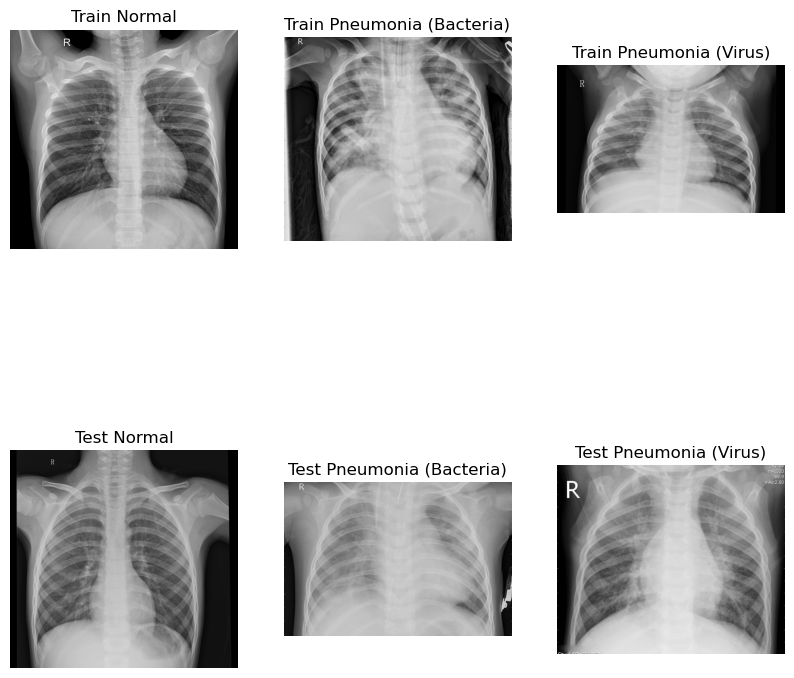

In [131]:
# check image - please hide the code and show output
# train data
train_normal = df[(df['dataset'] == 'train') & (df['label'] == 'NORMAL')].iloc[0]
ima1 = Image.open(train_normal['image_path'])
train_backteria = df[(df['dataset'] == 'train') &(df['sublabel'] == 'BACTERIA')].iloc[0]
ima2 = Image.open(train_backteria['image_path'])
train_virus = df[(df['dataset'] == 'train') &(df['sublabel'] == 'VIRUS')].iloc[0]
ima3 = Image.open(train_virus['image_path'])

# test data
test_normal = df[(df['dataset'] == 'test') & (df['label'] == 'NORMAL')].iloc[0]
ima4 = Image.open(test_normal['image_path'])
test_backteria =df[(df['dataset'] == 'test') & (df['sublabel'] == 'BACTERIA')].iloc[0]
ima5 = Image.open(test_backteria['image_path'])
test_virus =df[(df['dataset'] == 'test') & (df['sublabel'] == 'VIRUS')].iloc[0]
ima6 = Image.open(test_virus['image_path'])

# display example images
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes[0, 0].imshow(ima1, cmap ='gray'); axes[0, 0].set_title("Train Normal"); axes[0, 0].axis('off')
axes[0, 1].imshow(ima2, cmap='gray'); axes[0, 1].set_title("Train Pneumonia (Bacteria)"); axes[0, 1].axis('off')
axes[0, 2].imshow(ima3, cmap='gray'); axes[0, 2].set_title("Train Pneumonia (Virus)"); axes[0, 2].axis('off')
axes[1, 0].imshow(ima4, cmap='gray'); axes[1, 0].set_title("Test Normal"); axes[1, 0].axis('off')
axes[1, 1].imshow(ima5, cmap='gray'); axes[1, 1].set_title("Test Pneumonia (Bacteria)"); axes[1, 1].axis('off')
axes[1, 2].imshow(ima6, cmap='gray'); axes[1, 2].set_title("Test Pneumonia (Virus)"); axes[1, 2].axis('off')
plt.show()

In [132]:
# Summary statistics for image sizes
def clean_summary_table(table):
    table2 = table[table.index != 'count']
    table2 = table2.round({'X':0, 'Y':0, '#_of_pixels':0, 'aspect_ratio':2})
    for cn in ['X', 'Y', '#_of_pixels']:
        table2.loc[:,cn] = table2.loc[:,cn].astype(int).astype(str)
    return table2
img_size_list = []
for i in range(df.shape[0]):
    img_path = df.iloc[i]['image_path']
    img = Image.open(img_path)
    img_size_list.append(img.size)
img_size = pd.DataFrame(img_size_list, columns = ['X', 'Y'])
img_size.loc[:, '#_of_pixels'] = img_size.X * img_size.Y
img_size.loc[:, 'aspect_ratio'] = img_size.X / img_size.Y
img_size.loc[:, 'dataset'] = df.dataset
img_size.loc[:, 'sublabel'] = df.sublabel
for v1 in ['train', 'test']:
    for v2 in sublabel_categories:
        img_size_sub = img_size[np.array(img_size.dataset == v1) & np.array(img_size.sublabel == v2)]
        summary_table = clean_summary_table(img_size_sub.describe())
        print(v1+", "+v2+":")
        print(summary_table)
        print("\n")

train, NORMAL:
         X     Y #_of_pixels  aspect_ratio
mean  1667  1380     2384346          1.23
std    289   326     1005050          0.13
min    912   672      612864          0.88
25%   1466  1152     1701678          1.14
50%   1638  1325     2164036          1.22
75%   1820  1541     2775412          1.31
max   2916  2663     7532028          1.81


train, BACTERIA:
         X     Y #_of_pixels  aspect_ratio
mean  1164   803      998865          1.50
std    273   261      575892          0.24
min    399   144       62928          0.92
25%    985   632      625600          1.35
50%   1128   760      853760          1.48
75%   1312   931     1212096          1.64
max   2772  2272     5815656          3.27


train, VIRUS:
         X     Y #_of_pixels  aspect_ratio
mean  1269   867     1184714          1.53
std    311   300      681616          0.26
min    384   127       48768          0.84
25%   1072   664      702784          1.36
50%   1272   832     1055360          1.51
75% 

In [133]:
# check pixels
first_image =df.iloc[0]['image_path']
img = Image.open(first_image)
img_array = np.array(img)
pd.Series(img_array.flatten()).describe().round().astype(int).astype(str)

count    6368272
mean         121
std           60
min            0
25%           80
50%          133
75%          171
max          255
dtype: object